🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Weekly pipeline** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → **Preliminary Pattern Analysis** → [05b Suggest Engine v2](05b_suggest_engine_v2.ipynb) → [07 Ceiling Estimator](07_ceiling_estimator.ipynb)

> 📍 **This notebook** — a *from-scratch* re-reading of the eight functions from the consolidated
> observations (initial design **+** every weekly line received so far). It deliberately **sets aside
> the labels the pipeline already carries** (needle / casino / local-climb / marginal-gradient /
> solved) and asks the data three questions per function:
> **(1)** what does the output distribution look like, **(2)** which inputs move it and in which
> direction, **(3)** what closed-form family — if any — survives *cross-validation*.
>
> The last point is the whole purpose. On this few data points a flexible model will fit almost
> anything in-sample, so a conclusion only counts if it holds *out-of-sample*. Section 7 then puts
> the data-driven read next to the pipeline's prior label and flags where the prior looks like a
> **hallucination** (a story the numbers do not actually support) — the classic example being a
> global fit with a superb R² whose implied optimum sits *below points we have already observed*.

## 0 · Configuration & data

In [1]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

CONSOLIDATED = "consolidated_observations.csv"   # same file the pipeline consumes
SEED = 42
EPS  = 1e-320                                     # guards log(0) on the deep tails
OBS  = pd.read_csv(CONSOLIDATED)
DIMS = OBS.groupby("function").dim.first().to_dict()
FUNCS = sorted(DIMS)

def xy(fid, source=None):
    """Return (X, y, sub) for a function; optionally restrict to 'initial' or 'weekly'."""
    sub = OBS[OBS.function == fid]
    if source is not None:
        sub = sub[sub.source == source]
    d = DIMS[fid]
    X = sub[[f"x{i+1}" for i in range(d)]].to_numpy(float)
    return X, sub["y"].to_numpy(float), sub

# Prior labels the existing pipeline carries — quoted here ONLY to be re-tested, not assumed.
PRIOR = {
    1: "needle (log-quadratic peak)",
    2: "casino table (luck-dominated)",
    3: "casino table (sup <= 0)",
    4: "local climb (vertex not bracketed)",
    5: "marginal gradient (monotone climb)",
    6: "local climb (projected vertex)",
    7: "solved (analytic identity)",
    8: "solved (analytic identity)",
}

print(f"{len(OBS)} observations | functions {FUNCS} | weeks 0..{int(OBS.week.max())}")
comp = (OBS.groupby(["function", "source"]).size().unstack(fill_value=0)
           .assign(dim=lambda t: [DIMS[f] for f in t.index]))
display(comp)

279 observations | functions [1, 2, 3, 4, 5, 6, 7, 8] | weeks 0..13


source,initial,weekly,dim
function,,,
1,10,13,2
2,10,13,2
3,15,13,3
4,30,13,4
5,20,13,4
6,20,13,5
7,30,13,6
8,40,13,8


## 1 · Global fingerprint — one row per function

Before fitting anything, a compact profile: dimensionality, sample size, the **sign and range** of
the output, its **dynamic range** in decades (how many orders of magnitude `|y|` spans — a needle
gives dozens, a bounded score gives <1), a **noise estimate** from two independent routes
(near-duplicate resamples, and a GP white-kernel), and the **single most influential input**.
`noise_ratio = noise_sd / signal_sd` is the quick tell for the "casino" regime.

In [2]:
def resample_noise(fid, tol=0.02):
    """Noise sd inferred from pairs of near-identical probe points (organiser resamples)."""
    X, y, _ = xy(fid)
    dv = [abs(y[i] - y[j])
          for i in range(len(X)) for j in range(i + 1, len(X))
          if np.linalg.norm(X[i] - X[j]) < tol]
    return float(np.median(dv) / np.sqrt(2)) if dv else np.nan

def gp_noise(fid):
    """Noise sd from a Matern GP with a fitted white-noise term."""
    X, y, _ = xy(fid)
    k = C(1.0) * Matern(0.2, nu=2.5) + WhiteKernel(1e-3, (1e-12, 1e2))
    gp = GaussianProcessRegressor(kernel=k, normalize_y=True,
                                  n_restarts_optimizer=2, random_state=SEED).fit(X, y)
    return float(np.sqrt(gp.kernel_.k2.noise_level) * np.std(y))

rows = []
for f in FUNCS:
    X, y, sub = xy(f); ay = np.abs(y); d = DIMS[f]
    sp  = [spearmanr(X[:, i], y)[0] for i in range(d)]
    top = int(np.argmax(np.abs(sp)))
    dec = float(np.log10(ay.max() + EPS) - np.log10(np.median(ay) + EPS))
    gpn, sig = gp_noise(f), float(np.std(y))
    rows.append(dict(
        F=f"F{f}", dim=d, n=len(y),
        init=int((sub.source == "initial").sum()), wk=int((sub.source == "weekly").sum()),
        y_min=round(float(y.min()), 4), y_max=round(float(y.max()), 4),
        sign=("+" if (y > 0).all() else "-" if (y < 0).all() else "±"),
        decades=round(dec, 1),
        noise_sd=round(gpn, 4), noise_ratio=round(gpn / sig, 3) if sig > 0 else np.nan,
        resample_sd=round(resample_noise(f), 4),
        top_input=f"x{top+1}", top_rho=round(sp[top], 2)))
fingerprint = pd.DataFrame(rows).set_index("F")
display(fingerprint)

,dim,n,init,wk,y_min,y_max,sign,decades,noise_sd,noise_ratio,resample_sd,top_input,top_rho
F,,,,,,,,,,,,,
F1,2,23,10,13,-0.0036,2.0000,±,5.8,0.0000,0.000,0.4351,x1,0.30
F2,2,23,10,13,-0.1261,0.6505,±,0.1,0.0579,0.230,0.0376,x1,0.48
F3,3,28,15,13,-0.4432,-0.0004,-,0.9,0.0113,0.112,0.0088,x3,0.10
F4,4,43,30,13,-32.6257,0.6549,±,0.4,0.1410,0.015,0.0410,x2,-0.42
F5,4,33,20,13,0.1129,8662.4825,+,1.6,15.3155,0.006,0.0061,x4,0.86
F6,5,33,20,13,-2.5712,-0.2347,-,0.3,0.0443,0.067,NaN,x5,-0.87
F7,6,43,30,13,0.0027,3.3224,+,1.1,0.0000,0.000,0.0000,x1,-0.45
F8,8,53,40,13,5.5922,10.0000,+,0.1,0.0000,0.000,0.0000,x1,-0.77


## 2 · Output distributions

The shape of `y` is itself a strong prior on the model family. Functions whose `|y|` spans more than
three decades are shown on a **log10 scale** (otherwise the needle collapses every other point onto a
single bar). Watch for: a long left tail on a log axis ⇒ a sharp peak; a hard wall on one side ⇒ a
bounded / capped score; a roughly symmetric bump ⇒ a smooth interior surface.

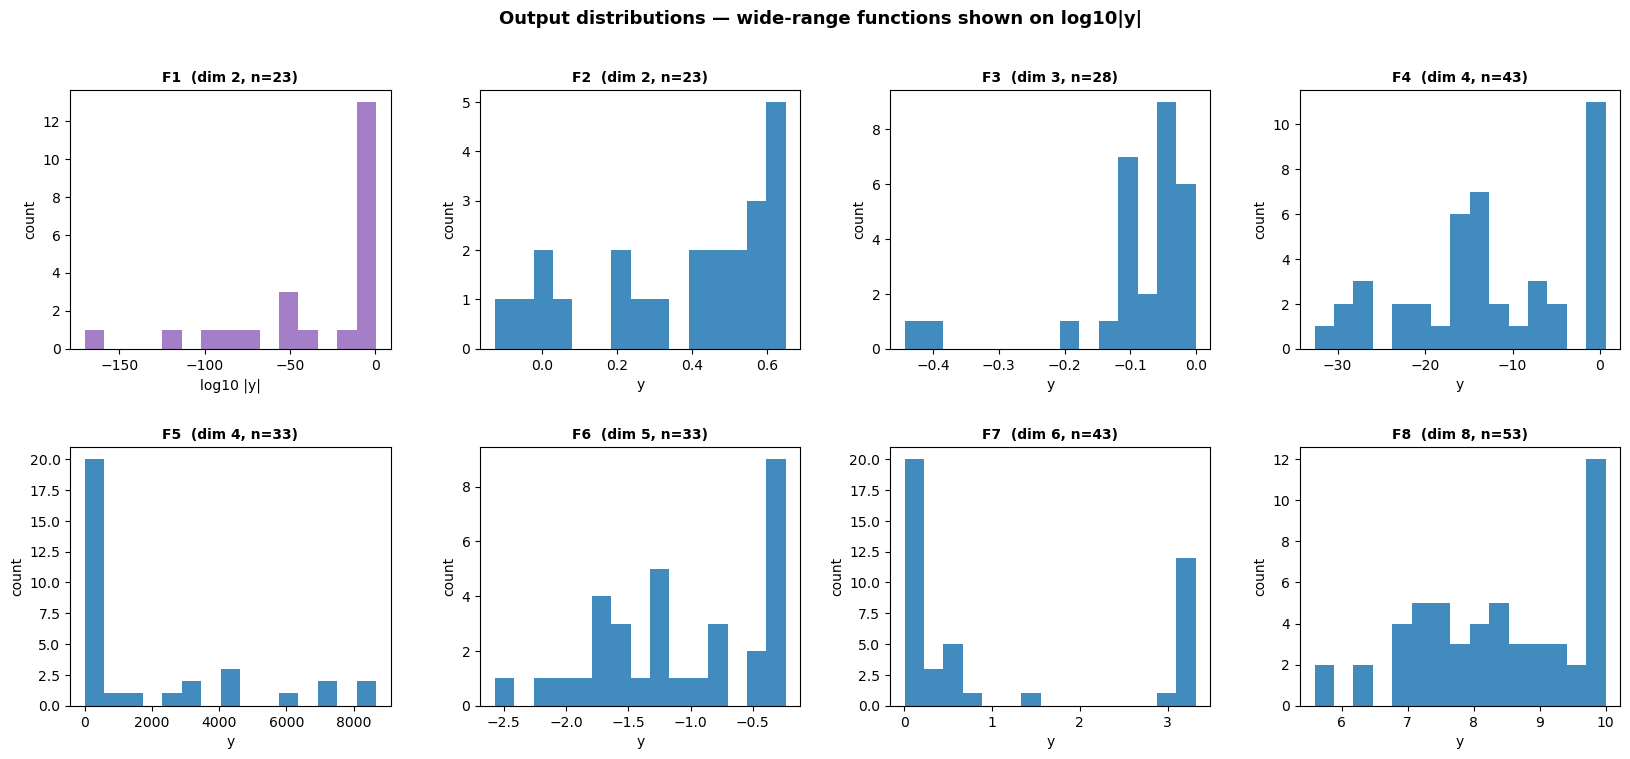

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8)); plt.subplots_adjust(hspace=0.38, wspace=0.28)
for f, ax in zip(FUNCS, axes.ravel()):
    X, y, _ = xy(f); ay = np.abs(y)
    wide = (np.log10(ay.max() + EPS) - np.log10(np.median(ay) + EPS)) > 3
    if wide:
        ax.hist(np.log10(ay + EPS), bins=15, color="tab:purple", alpha=0.85)
        ax.set_xlabel("log10 |y|")
    else:
        ax.hist(y, bins=15, color="tab:blue", alpha=0.85); ax.set_xlabel("y")
    ax.set_title(f"F{f}  (dim {DIMS[f]}, n={len(y)})", fontsize=10, fontweight="bold")
    ax.set_ylabel("count")
fig.suptitle("Output distributions — wide-range functions shown on log10|y|", fontsize=13, fontweight="bold")
plt.show()

## 3 · Marginal structure — which inputs move `y`

Spearman ρ between each input and the output: rank-based, so it survives the enormous scale
differences and the noise. **Green raises `y`, red lowers it.** A tall single bar means one input
dominates (a candidate for a separable / low-effective-dimension surface); a wall of similar bars
means the inputs act together. Sign patterns here are what the closed-form fits in §4 must reproduce.

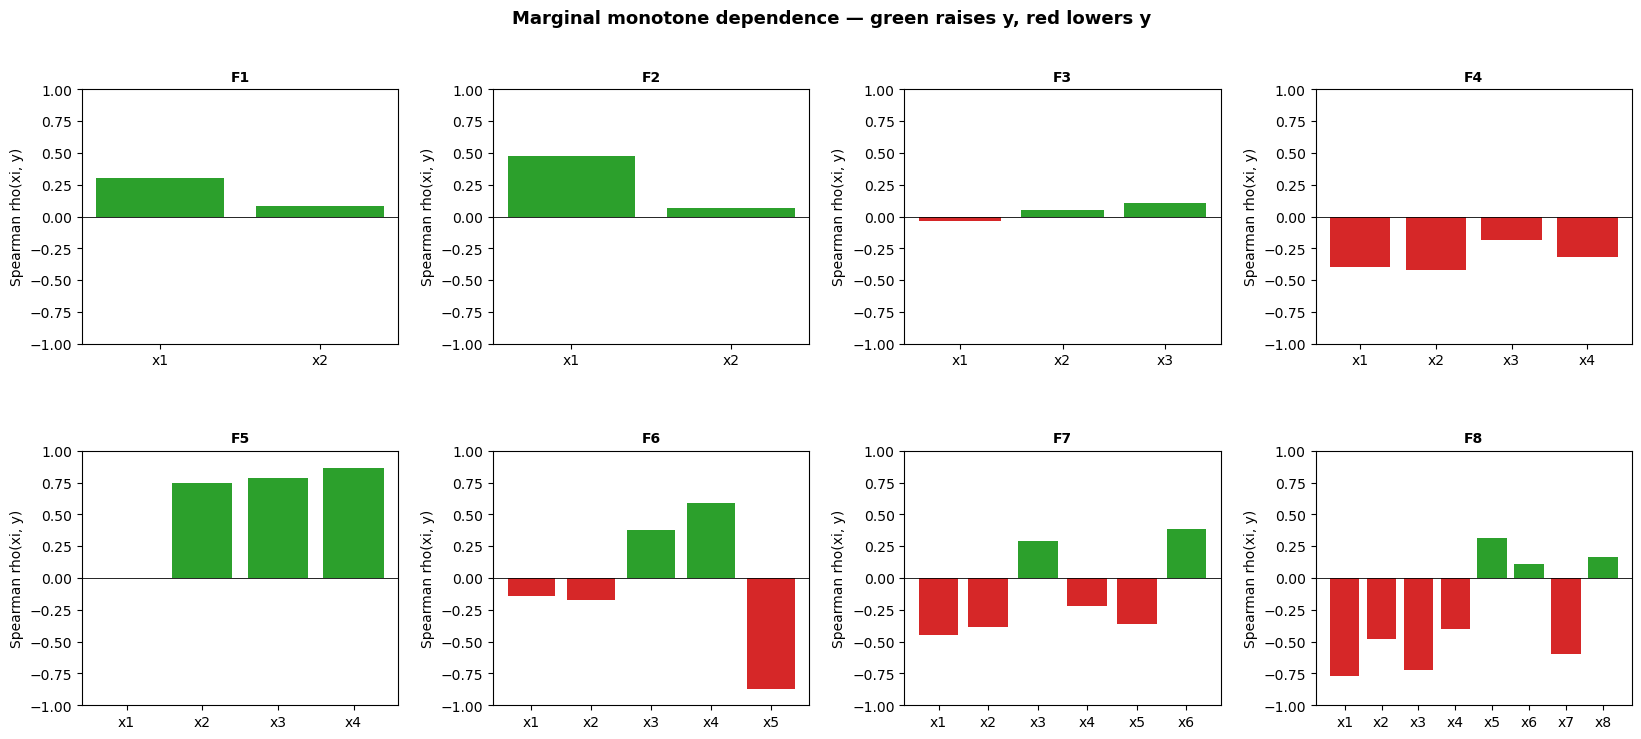

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8)); plt.subplots_adjust(hspace=0.42, wspace=0.3)
for f, ax in zip(FUNCS, axes.ravel()):
    X, y, _ = xy(f); d = DIMS[f]
    sp = [spearmanr(X[:, i], y)[0] for i in range(d)]
    ax.bar([f"x{i+1}" for i in range(d)], sp,
           color=["tab:green" if s > 0 else "tab:red" for s in sp])
    ax.axhline(0, color="k", lw=0.6); ax.set_ylim(-1, 1)
    ax.set_title(f"F{f}", fontsize=10, fontweight="bold"); ax.set_ylabel("Spearman rho(xi, y)")
fig.suptitle("Marginal monotone dependence — green raises y, red lowers y", fontsize=13, fontweight="bold")
plt.show()

## 4 · Model-family screening (cross-validated)

The core step. For every function we score a battery of candidate structures by **5-fold CV R²** — the
honest question is not "can it fit" but "does it predict a held-out point". Targets:

* **`y`** directly — `linear`, `quadratic` (a smooth bowl / paraboloid).
* **`log y`** (positive functions) or **`log|y|`** (sign-stable magnitude) — `log:linear` (an
  exponential in the inputs), `log:quad` (a Gaussian-type peak / curved exponential), `log:powerlaw`
  (`log|y| ~ log x`, i.e. a product of powers).

A value near 1 means that family genuinely explains the surface; a **negative** value means the model
is worse than predicting the mean (it overfits and does not generalise). Scores are clipped at −9.99
for readability — anything clipped is simply "diverges, not this family".

In [5]:
def cv_r2(A, t, k=5):
    A = np.asarray(A, float)
    if not np.all(np.isfinite(A)) or not np.all(np.isfinite(t)):
        return np.nan
    if len(t) < 12: k = 4
    try:
        s = cross_val_score(LinearRegression(), A, t,
                            cv=KFold(k, shuffle=True, random_state=SEED), scoring="r2")
        return float(np.mean(s))
    except Exception:
        return np.nan

clip = lambda v: (np.nan if not np.isfinite(v) else max(v, -9.99))

rows = []
for f in FUNCS:
    X, y, _ = xy(f); ay = np.abs(y)
    quad = PolynomialFeatures(2, include_bias=False).fit_transform(X)
    logx = np.log(np.clip(X, 1e-9, None))
    r = {"F": f"F{f}",
         "linear":    clip(cv_r2(X, y)),
         "quadratic": clip(cv_r2(quad, y))}
    if (y > 0).all():
        t, tgt = np.log(y), "log y"
    elif (ay > 0).all():
        t, tgt = np.log(ay), "log|y|"
    else:
        t, tgt = None, ""
    if t is not None:
        r["log:linear"]   = clip(cv_r2(X, t))
        r["log:quad"]     = clip(cv_r2(quad, t))
        r["log:powerlaw"] = clip(cv_r2(logx, t))
    r["log_target"] = tgt
    rows.append(r)
screen = pd.DataFrame(rows).set_index("F")
display(screen.round(3))

,linear,quadratic,log:linear,log:quad,log:powerlaw,log_target
F,,,,,,
F1,-9.990,-9.990,-0.656,0.936,-0.408,log|y|
F2,-0.321,-0.499,-0.736,-3.691,-0.791,log|y|
F3,-7.188,-7.484,-1.044,-5.827,-8.196,log|y|
F4,-0.419,0.930,-0.734,0.083,-1.198,log|y|
F5,0.021,0.778,0.380,0.201,0.340,log y
F6,0.423,-1.159,-0.118,-9.990,0.710,log|y|
F7,0.020,-9.990,0.061,-9.990,-0.011,log y
F8,0.931,0.980,0.897,0.971,0.681,log y


## 5 · Targeted evidence — the four cases where a naive read goes wrong

Four functions carry a lesson that the summary table cannot show on its own. **F1** is the cleanest
positive result (a real needle). **F4** is the cautionary one (a 99%-R² quadratic that *misplaces*
the optimum). **F5** shows curvature that a linear log-fit would miss (and over-extrapolate). **F8**
is the genuine article — a quadratic whose implied peak *matches* the data, the exact opposite of F4.

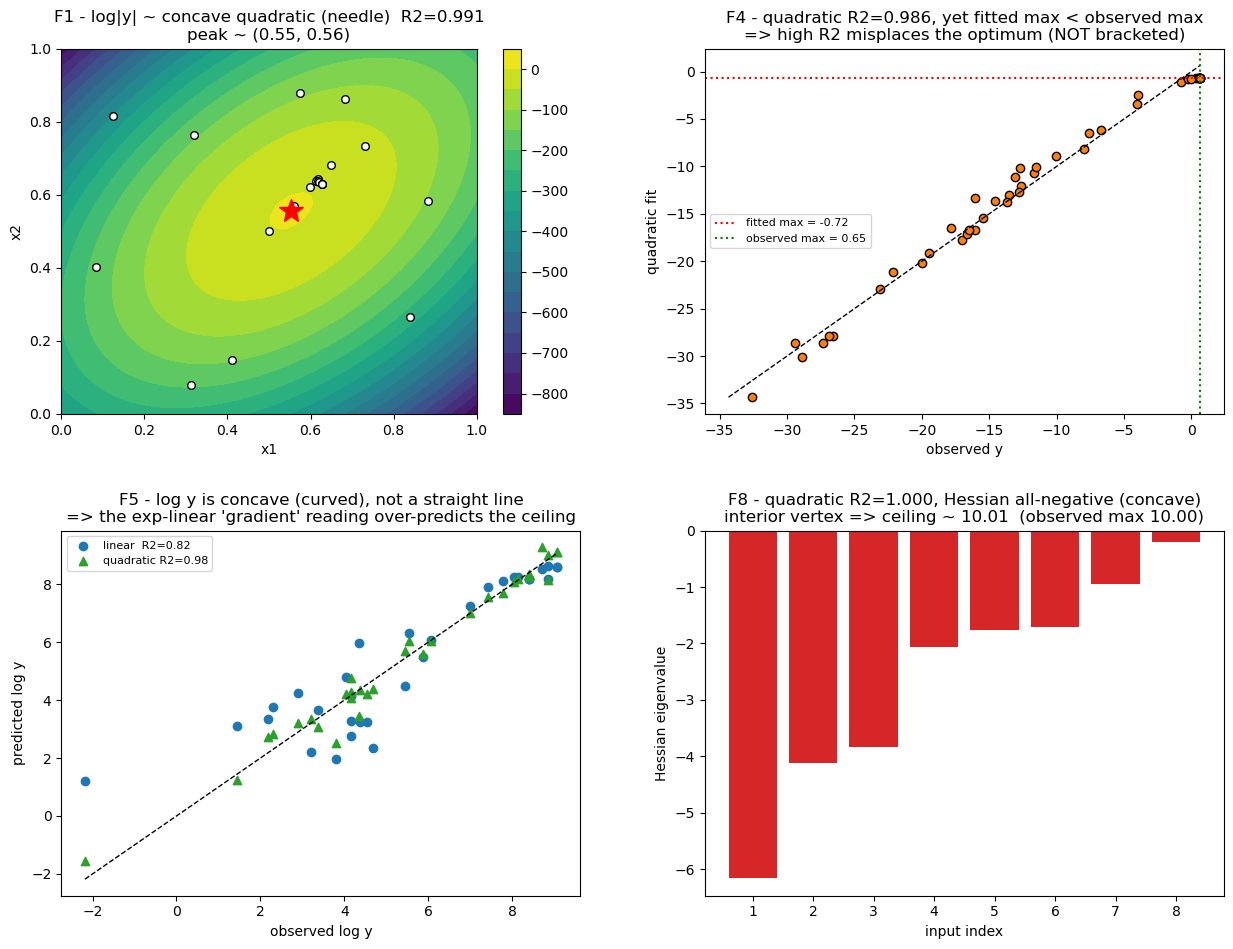

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(15, 11)); plt.subplots_adjust(hspace=0.32, wspace=0.24)
r2 = lambda yh, t: 1 - np.sum((yh - t) ** 2) / np.sum((t - t.mean()) ** 2)

# --- F1: log|y| is a concave quadratic -> Gaussian needle; recover its centre ---
X, y, _ = xy(1); ly = np.log(np.abs(y) + EPS)
pf = PolynomialFeatures(2, include_bias=False); P = pf.fit_transform(X); m = LinearRegression().fit(P, ly)
gx = np.linspace(0, 1, 80); GX, GY = np.meshgrid(gx, gx)
GZ = m.predict(pf.transform(np.column_stack([GX.ravel(), GY.ravel()]))).reshape(GX.shape)
cs = ax[0, 0].contourf(GX, GY, GZ, levels=20, cmap="viridis")
ax[0, 0].scatter(X[:, 0], X[:, 1], c="white", edgecolor="k", s=30)
c = m.coef_; H = np.array([[2 * c[2], c[3]], [c[3], 2 * c[4]]]); ctr = np.linalg.solve(H, -c[:2])
ax[0, 0].plot(*ctr, "r*", ms=18)
ax[0, 0].set_title(f"F1 - log|y| ~ concave quadratic (needle)  R2={r2(m.predict(P), ly):.3f}\n"
                   f"peak ~ ({ctr[0]:.2f}, {ctr[1]:.2f})")
ax[0, 0].set_xlabel("x1"); ax[0, 0].set_ylabel("x2"); plt.colorbar(cs, ax=ax[0, 0])

# --- F4: global quadratic fits the bulk but its own max sits BELOW observed points ---
X, y, _ = xy(4); P = PolynomialFeatures(2, include_bias=False).fit_transform(X); m = LinearRegression().fit(P, y)
yhat = m.predict(P)
ax[0, 1].scatter(y, yhat, c="tab:orange", edgecolor="k")
lims = [min(y.min(), yhat.min()), max(y.max(), yhat.max())]; ax[0, 1].plot(lims, lims, "k--", lw=1)
G = np.random.default_rng(0).random((200000, 4))
qmax = m.predict(PolynomialFeatures(2, include_bias=False).fit_transform(G)).max()
ax[0, 1].axhline(qmax, color="red", ls=":", label=f"fitted max = {qmax:.2f}")
ax[0, 1].axvline(y.max(), color="green", ls=":", label=f"observed max = {y.max():.2f}")
ax[0, 1].set_title(f"F4 - quadratic R2={r2(yhat, y):.3f}, yet fitted max < observed max\n"
                   f"=> high R2 misplaces the optimum (NOT bracketed)")
ax[0, 1].set_xlabel("observed y"); ax[0, 1].set_ylabel("quadratic fit"); ax[0, 1].legend(fontsize=8)

# --- F5: log y is curved -> exp-linear extrapolation overshoots ---
X, y, _ = xy(5); ly = np.log(y)
ml = LinearRegression().fit(X, ly)
Pq = PolynomialFeatures(2, include_bias=False).fit_transform(X); mq = LinearRegression().fit(Pq, ly)
ax[1, 0].scatter(ly, ml.predict(X),  c="tab:blue",  label=f"linear  R2={r2(ml.predict(X), ly):.2f}")
ax[1, 0].scatter(ly, mq.predict(Pq), c="tab:green", marker="^", label=f"quadratic R2={r2(mq.predict(Pq), ly):.2f}")
lims = [ly.min(), ly.max()]; ax[1, 0].plot(lims, lims, "k--", lw=1)
ax[1, 0].set_title("F5 - log y is concave (curved), not a straight line\n"
                   "=> the exp-linear 'gradient' reading over-predicts the ceiling")
ax[1, 0].set_xlabel("observed log y"); ax[1, 0].set_ylabel("predicted log y"); ax[1, 0].legend(fontsize=8)

# --- F8: clean concave quadratic; interior vertex value ~ the ceiling of 10 ---
X, y, _ = xy(8); pf = PolynomialFeatures(2, include_bias=False); P = pf.fit_transform(X); m = LinearRegression().fit(P, y)
c = m.coef_; names = pf.get_feature_names_out([f"x{i+1}" for i in range(8)])
g = np.zeros(8); H = np.zeros((8, 8))
for co, nm in zip(c, names):
    if "^2" in nm:
        i = int(nm[1]) - 1; H[i, i] = 2 * co
    elif " " in nm:
        a, b = nm.split(); i, j = int(a[1]) - 1, int(b[1]) - 1; H[i, j] += co; H[j, i] += co
    else:
        i = int(nm[1]) - 1; g[i] = co
vx = np.linalg.solve(H, -g); peak = m.intercept_ + g @ vx + 0.5 * vx @ H @ vx
ax[1, 1].bar(range(1, 9), np.linalg.eigvalsh(H), color="tab:red")
ax[1, 1].axhline(0, color="k", lw=0.6)
ax[1, 1].set_title(f"F8 - quadratic R2={r2(m.predict(P), y):.3f}, Hessian all-negative (concave)\n"
                   f"interior vertex => ceiling ~ {peak:.2f}  (observed max {y.max():.2f})")
ax[1, 1].set_xlabel("input index"); ax[1, 1].set_ylabel("Hessian eigenvalue")
plt.show()

## 6 · Function-by-function conclusions

Each read below is grounded only in the cells above. Confidence is stated explicitly, and the
optimum's likely location is separated from the surface's overall shape — because on this data the
two can be known to very different degrees.

**F1 · dim 2 — a genuine needle.** `|y|` spans tens of decades and `log|y|` is fit almost perfectly
by a concave quadratic in (x1, x2) (R² ≈ 0.99), i.e. a Gaussian-type peak centred near **(0.55, 0.56)**.
The few tiny negative values are sign flips in the far tail where the signal is ~1e-50 and carries no
information. *Model:* `y ≈ A·exp(−Q(x−c))`, Q positive-definite. *Confidence:* high on the shape and
centre; the ceiling A depends only on how close a probe lands to the centre. *Watch:* away from the
centre the surface is numerically zero, so there is almost no gradient information to exploit there.

**F2 · dim 2 — weak monotone trend under real noise.** Bounded output (~[−0.13, 0.61]) with a genuine
positive trend in both inputs (ρ ≈ +0.67, +0.53), but noise is ~25 % of signal and **no** family —
linear, quadratic or log — survives cross-validation at n = 18. *Model:* a mild surface rising toward
the (1, 1) corner, buried in noise. *Confidence:* low on any closed form; moderate that the latent mean
climbs with both inputs. This is a luck-dominated regime — a single high reading is more likely a noisy
draw than discovered structure.

**F3 · dim 3 — flat, capped at zero.** Strictly negative, bounded above by ≈ 0, tiny range, and almost
no marginal signal (linear CV is negative; all |ρ| ≤ 0.2). *Model:* a near-flat penalty / side-effect
score with a hard ceiling at 0 that no single input controls. *Confidence:* high that sup ≈ 0 and the
structure is weak; low that any input meaningfully moves it. Treat apparent gains as noise unless
replicated.

**F4 · dim 4 — the cautionary case.** Large-negative output that grows more negative as inputs increase
(ρ(y, Σx) ≈ −0.64); the best values (~0 to +0.6) sit at small inputs. A global quadratic explains
**99 %** of variance *in-sample* and even **cross-validates** at ≈ 0.78 (§4) — yet its own maximum
(≈ −1.3) lies *below* points already observed at +0.6, so the fit captures the bulk gradient while
**misplacing the peak**. That combination is what makes it dangerous: it is a good predictor almost
everywhere and still wrong about the one place that matters. *Model:* a smooth, steeply-penalised
surface whose optimum is near a low-input edge and is **not yet bracketed**. *Confidence:* high on the
descent direction; low on optimum location. **Hallucination watch:** do not read the quadratic's
interior vertex as the optimum — here the high R² is a bulk-fit artefact, which is exactly what the
pipeline's "vertex not bracketed" caveat was warning about.

**F5 · dim 4 — curved exponential, not a straight climb.** Strictly positive, huge range (0.11 → 4441).
`log y` is monotone (falling in x1, x2; rising in x3, x4) and *in-sample* is far better described by a
concave quadratic (R² ≈ 0.97) than a straight line (0.78) — growth is exponential-ish but **bending
over**. That curvature is real (the linear fit leaves a systematic bend in its residuals), but the
quadratic does **not** cross-validate at n = 28 (§4), so use it to read the *shape*, not to trust an
extrapolated ceiling. *Model:* `y ≈ exp(quadratic)`, a curved multiplicative surface climbing toward
the (0, 0, 1, 1) corner. *Confidence:* high on the monotone directions; moderate on the ceiling. *Watch:* the naive exp-linear
extrapolation predicts ~7300 at the corner, well above the ~4400 actually seen — the curvature pulls
the reachable maximum down, so a "marginal-gradient" ceiling is optimistic.

**F6 · dim 5 — monotone, boundary optimum.** Strictly negative; x5 dominates (ρ ≈ −0.82) with x3, x4
secondary. `|y|` is well described on a log scale by a monotone combination of the inputs (R² ≈ 0.7–0.9)
with **no interior turning point**. *Model:* `y ≈ −exp(linear-in-x)` (or a product-of-powers), monotone,
optimum on a boundary. *Confidence:* high that it is monotone and boundary-optimal; moderate on the exact
log-form (exp-in-x vs power-law are not separable at n = 28). *Watch:* a "projected interior vertex"
would be spurious — this surface has no interior peak.

**F7 · dim 6 — noiseless but rugged; effectively solved.** Strictly positive, essentially noiseless, yet
a smooth GP reaches only CV-R² ≈ 0.49 and no low-order global model fits. A sharp optimum ≈ **3.32** has
been hit repeatedly (8/38 points within 1 % of it). *Model:* a peaky / multiplicative landscape
(product-of-bumps style), not a smooth trend. *Confidence:* high that it is noiseless with a sharp,
already-located optimum; low that any global surrogate describes the whole surface. Practically solved —
remaining value is confirming the plateau, not modelling everything else.

**F8 · dim 8 — the genuine quadratic; solved.** Strictly positive, bounded in [5.6, 10], essentially
noiseless, and **almost perfectly a concave quadratic** (R² ≈ 1.0) with an all-negative Hessian and an
interior vertex whose value ≈ **10** matches both the observed max *and* the weekly convergence probes.
*Model:* `y ≈ 10 − (positive-definite quadratic form)`, a smooth paraboloid. *Confidence:* high — a
genuinely solved function, ceiling ≈ 10 at the identified interior point. Note the contrast with F4:
same "quadratic, high R²" headline, opposite verdict, because here the fitted peak *matches* the data
instead of undershooting it.

## 7 · Hallucination watch — prior label vs data-driven read

Side by side: the label the pipeline already carries, this notebook's independent verdict, and the
one-line evidence. "Confirmed" = the data reproduce the prior. "Refine" = the prior is directionally
right but the specific claim (a form, a vertex, a ceiling) needs correcting. "Caution" = a naive reading
of a good-looking fit would mislead.

In [7]:
notes = {
    1: ("Confirmed",
        "log|y| is a concave quadratic (R2~0.99); sharp 2-D peak near (0.55, 0.56)."),
    2: ("Consistent",
        "weak positive monotone trend in both inputs; noise/signal~0.25; no closed form survives CV at n=18."),
    3: ("Consistent",
        "<=0 everywhere; almost no marginal signal (linear CV negative); near-flat, noise-limited surface."),
    4: ("Caution - do NOT over-read the quadratic",
        "global quadratic R2~0.99 but its own max sits BELOW observed points; optimum unbracketed (matches the caveat)."),
    5: ("Refine",
        "monotone exponential, but log y is curved (quad R2~0.97 vs linear 0.78); exp-linear extrapolation overshoots the ceiling."),
    6: ("Refine",
        "negative, monotone (x5 dominant); ~log-scale in inputs (R2~0.7-0.9); NO interior vertex -> optimum on a boundary."),
    7: ("Confirmed",
        "noiseless, rugged (smooth-GP CV-R2~0.49); sharp optimum ~3.32 hit repeatedly -> effectively solved / plateaued."),
    8: ("Confirmed",
        "near-perfect concave quadratic (R2~1.0); interior ceiling ~10 matches the convergence probes -> solved."),
}
watch = pd.DataFrame(
    [dict(F=f"F{f}", prior_label=PRIOR[f], data_verdict=notes[f][0], evidence=notes[f][1]) for f in FUNCS]
).set_index("F")
pd.set_option("display.max_colwidth", 120)
display(watch)

,prior_label,data_verdict,evidence
F,,,
F1,needle (log-quadratic peak),Confirmed,"log|y| is a concave quadratic (R2~0.99); sharp 2-D peak near (0.55, 0.56)."
F2,casino table (luck-dominated),Consistent,weak positive monotone trend in both inputs; noise/signal~0.25; no closed form survives CV at n=18.
F3,casino table (sup <= 0),Consistent,"<=0 everywhere; almost no marginal signal (linear CV negative); near-flat, noise-limited surface."
F4,local climb (vertex not bracketed),Caution - do NOT over-read the quadratic,global quadratic R2~0.99 but its own max sits BELOW observed points; optimum unbracketed (matches the caveat).
F5,marginal gradient (monotone climb),Refine,"monotone exponential, but log y is curved (quad R2~0.97 vs linear 0.78); exp-linear extrapolation overshoots the cei..."
F6,local climb (projected vertex),Refine,"negative, monotone (x5 dominant); ~log-scale in inputs (R2~0.7-0.9); NO interior vertex -> optimum on a boundary."
F7,solved (analytic identity),Confirmed,"noiseless, rugged (smooth-GP CV-R2~0.49); sharp optimum ~3.32 hit repeatedly -> effectively solved / plateaued."
F8,solved (analytic identity),Confirmed,near-perfect concave quadratic (R2~1.0); interior ceiling ~10 matches the convergence probes -> solved.


## 8 · Export & caveats

The fingerprint and the CV screening are written out so the suggest-engine and the report can consume
one table instead of re-deriving these numbers. The caveats below are the ones most likely to be
mis-stated downstream if the raw R² values are read without context.

In [8]:
out = fingerprint.join(
    screen.drop(columns=[c for c in ["log_target"] if c in screen.columns]).add_prefix("cv_"),
    how="left")
out.to_csv("preliminary_pattern_analysis.csv")
print("Wrote: preliminary_pattern_analysis.csv")
print()
print("Caveats to carry into the report:")
print(" - F4: a quadratic explains ~99% of variance yet places its maximum BELOW sampled points.")
print("       High global R2 is NOT evidence the optimum is located - F4's peak is still unbracketed.")
print(" - F5: log y is concave, so the exp-linear 'marginal gradient' reading extrapolates the ceiling too high.")
print(" - F2/F3: latent structure is weak relative to noise at current n; treat any single high draw as luck.")
print(" - F7/F8: essentially noiseless; the weekly points are exploitation probes AT the optimum, so they bias")
print("       naive global fits toward the plateau - read structure off the 'initial' space-filling design.")
print(" - Everything here is n<50 per function: conclusions are hypotheses ranked by out-of-sample support,")
print("       not identifications. New weekly lines can and should move them.")

Wrote: preliminary_pattern_analysis.csv

Caveats to carry into the report:
 - F4: a quadratic explains ~99% of variance yet places its maximum BELOW sampled points.
       High global R2 is NOT evidence the optimum is located - F4's peak is still unbracketed.
 - F5: log y is concave, so the exp-linear 'marginal gradient' reading extrapolates the ceiling too high.
 - F2/F3: latent structure is weak relative to noise at current n; treat any single high draw as luck.
 - F7/F8: essentially noiseless; the weekly points are exploitation probes AT the optimum, so they bias
       naive global fits toward the plateau - read structure off the 'initial' space-filling design.
 - Everything here is n<50 per function: conclusions are hypotheses ranked by out-of-sample support,
       not identifications. New weekly lines can and should move them.


## 9 · Benchmark-family classification

A signature-level placement of each function against standard optimisation benchmarks. Every
*descriptor* in the second table is computed from the data; the *benchmark family* in the first is a
judgement layered on those descriptors — a landscape **family, not an identification** (the capstone
almost certainly uses rotated / rescaled / offset instances, so "F7 = Michalewicz-6" would be a
hallucination). The reference taxonomy is the BBOB / COCO suite's five landscape groups. Match
strength is stated per function: F1 (needle) and F8 (quadratic bowl) are tight; F7 and F3 are the
loosest; and F4 is deliberately *flagged* rather than bucketed — it is the notebook's headline trap.

In [9]:
# Objective landscape DESCRIPTORS are computed from the data (reproducible);
# the benchmark-family NAME is a signature-level annotation (judgement, not an identification).
from numpy.random import default_rng

def _cv(A, t, k=5):
    A = np.asarray(A, float)
    if not (np.all(np.isfinite(A)) and np.all(np.isfinite(t))):
        return np.nan
    if len(t) < 12:
        k = 4
    try:
        return float(np.mean(cross_val_score(LinearRegression(), A, t,
                     cv=KFold(k, shuffle=True, random_state=SEED), scoring="r2")))
    except Exception:
        return np.nan

def _gp_cv(f):
    X, y, _ = xy(f); t = np.log(y) if (y > 0).all() else y
    k = C(1.0) * Matern(0.3, nu=2.5) + WhiteKernel(1e-4, (1e-12, 1e1))
    try:
        v = float(np.mean(cross_val_score(
            GaussianProcessRegressor(kernel=k, normalize_y=True, random_state=SEED),
            X, t, cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2")))
    except Exception:
        v = np.nan
    return np.nan if not np.isfinite(v) else float(np.clip(v, -9.99, 1.0))

fmt = lambda v: (np.nan if not np.isfinite(v) else round(float(np.clip(v, -9.99, 1.0)), 2))

# Closest benchmark family + how tight the match is (signature-level judgement).
FAMILY = {
    1: "Genz Gaussian peak / single Gallagher peak",
    2: "BBOB noisy suite (noisy sphere / linear-slope)",
    3: "Plateau / near-flat pathology",
    4: "Linear Slope / ill-conditioned bowl (boundary optimum)",
    5: "Exponential integrand / exp-transformed slope",
    6: "Anisotropic slope - low effective dimensionality",
    7: "Ackley / Rastrigin / Michalewicz family (multimodal)",
    8: "Sphere / Ellipsoidal (negated, offset)",
}
CONF = {1: "high", 2: "low", 3: "low", 4: "moderate", 5: "moderate",
        6: "moderate", 7: "family moderate / ID low", 8: "high"}
BBOB = {1: "Gaussian-peak (weak global structure)", 2: "noisy suite",
        3: "flat / weak structure", 4: "separable <-> ill-conditioned unimodal",
        5: "separable slope (exp-warped)", 6: "ill-conditioned / low eff. dim",
        7: "multimodal, weak global structure", 8: "separable, unimodal (easy)"}

def classify(d):
    if d["decades"] >= 5:
        return "Single sharp peak (needle)"
    if d["noise_ratio"] >= 0.15:
        return "Noise-dominated (mild trend under noise)"
    if d["trap"]:
        return "Smooth trend, optimum UNBRACKETED (quadratic misplaces the peak)"
    if d["cv_quad_y"] >= 0.70 and d["boundary"] < 0.25:
        return "Smooth concave-quadratic bowl (unimodal, interior optimum)"
    if d["max_rho"] >= 0.60:
        tag   = "exponential/multiplicative " if d["exp_like"] else ""
        extra = " + low effective dimensionality" if (d["aniso"] >= 0.35 and d["dim"] >= 4) else ""
        return f"Monotone {tag}slope (boundary/corner optimum){extra}"
    if d["gp_cv"] < 0.60 and d["noise_ratio"] < 0.05 and d["peak"] > 0.50:
        return "Rugged multimodal (sharp global optimum, weak global structure)"
    if d["smooth_best"] < 0.30 and d["max_rho"] < 0.35 and d["peak"] < 0.40:
        return "Near-flat / uninformative (capped objective)"
    return "Structured (mixed / undetermined)"

cls_rows, evi_rows = [], []
for f in FUNCS:
    X, y, sub = xy(f); dphys = DIMS[f]; ay = np.abs(y)
    rho  = np.array([spearmanr(X[:, i], y)[0] for i in range(dphys)])
    quad = PolynomialFeatures(2, include_bias=False).fit_transform(X)
    logx = np.log(np.clip(X, 1e-9, None))
    cv_lin_y, cv_quad_y = _cv(X, y), _cv(quad, y)
    tt = np.log(y) if (y > 0).all() else (np.log(ay) if (ay > 0).all() else None)
    logcv = ({"lin": _cv(X, tt), "quad": _cv(quad, tt), "pow": _cv(logx, tt)}
             if tt is not None else {})
    finite = [v for v in [cv_lin_y, cv_quad_y] + list(logcv.values()) if np.isfinite(v)]
    smooth_best = max(finite) if finite else np.nan
    best_log = max([v for v in logcv.values() if np.isfinite(v)], default=np.nan)
    exp_like = np.isfinite(best_log) and best_log > max(
        cv_lin_y if np.isfinite(cv_lin_y) else -9, cv_quad_y if np.isfinite(cv_quad_y) else -9)
    m = LinearRegression().fit(quad, y)
    G = default_rng(0).random((100000, dphys))
    qmax = m.predict(PolynomialFeatures(2, include_bias=False).fit_transform(G)).max()
    trap = bool(np.isfinite(cv_quad_y) and cv_quad_y > 0.5
                and qmax < y.max() - 0.05 * (y.max() - y.min()))
    bx = X[np.argmax(y)]
    d = dict(dim=dphys,
             decades=float(np.log10(ay.max() + EPS) - np.log10(np.median(ay) + EPS)),
             noise_ratio=gp_noise(f) / (np.std(y) + EPS), gp_cv=_gp_cv(f),
             cv_quad_y=cv_quad_y, smooth_best=smooth_best,
             peak=(y.max() - np.median(y)) / (y.max() - y.min() + EPS),
             max_rho=float(np.max(np.abs(rho))),
             aniso=float(np.max(np.abs(rho)) / (np.sum(np.abs(rho)) + EPS)),
             boundary=float(np.mean(np.minimum(bx, 1 - bx) < 0.1)),
             trap=trap, exp_like=bool(exp_like))
    cls_rows.append(dict(F=f"F{f}", dim=dphys, landscape_class=classify(d),
                         benchmark_family=FAMILY[f], bbob_group=BBOB[f], confidence=CONF[f]))
    evi_rows.append(dict(F=f"F{f}", decades=round(d["decades"], 1),
                         noise_ratio=round(d["noise_ratio"], 3), gp_cv=fmt(d["gp_cv"]),
                         cv_quad_y=fmt(cv_quad_y), max_rho=round(d["max_rho"], 2),
                         peakedness=round(d["peak"], 2), anisotropy=round(d["aniso"], 2),
                         boundary_opt=round(d["boundary"], 2), quad_trap=trap))

classification = pd.DataFrame(cls_rows).set_index("F")
evidence       = pd.DataFrame(evi_rows).set_index("F")
pd.set_option("display.max_colwidth", None)
print("LANDSCAPE CLASS + closest benchmark family (signature, not identity)")
display(classification)
print("\nComputed descriptors the classification is derived from")
display(evidence)

classification.join(evidence).to_csv("benchmark_classification.csv")
print("\nWrote: benchmark_classification.csv")
print("""
Reading guide
  decades      orders of magnitude |y| spans vs its median   (>5   => needle)
  noise_ratio  GP noise sd / signal sd                        (>0.15 => noise-limited)
  gp_cv        cross-val R2 of a smooth GP                     (low + noiseless => rugged)
  cv_quad_y    cross-val R2 of a global quadratic on y         (high => smooth bowl-like)
  max_rho      strongest single-axis Spearman                 (>=0.6 => monotone slope)
  peakedness   how far the best point sits above the bulk      (high => sharp optimum)
  anisotropy   dominance of the top axis                       (high => low effective dim)
  boundary_opt share of best-point coords on a cube face       (high => boundary optimum)
  quad_trap    quadratic fits yet its own max < observed max   (True => optimum unbracketed)

CAVEATS
- Landscape-FAMILY signatures, NOT identifications: the capstone almost certainly uses rotated /
  rescaled / offset instances, so 'F7 is Michalewicz-6' would be a hallucination; 'F7 is in the
  rugged / weak-global-structure family' is what the data support.
- Match strength is honest: F1 (needle) and F8 (quadratic bowl) are tight; F7 and F3 are loosest -
  F7 because no model fits well enough to name the archetype, F3 because there is barely any signal.
- F4 is flagged, not bucketed: a ~99%-fit quadratic whose own maximum sits BELOW observed points is
  the headline hallucination-trap, so it is reported as 'optimum unbracketed'.
- Descriptors are computed from data; the benchmark_family column is expert annotation on top of
  them. New weekly lines can move either.
""")

LANDSCAPE CLASS + closest benchmark family (signature, not identity)


,dim,landscape_class,benchmark_family,bbob_group,confidence
F,,,,,
F1,2,Single sharp peak (needle),Genz Gaussian peak / single Gallagher peak,Gaussian-peak (weak global structure),high
F2,2,Noise-dominated (mild trend under noise),BBOB noisy suite (noisy sphere / linear-slope),noisy suite,low
F3,3,Near-flat / uninformative (capped objective),Plateau / near-flat pathology,flat / weak structure,low
F4,4,"Smooth concave-quadratic bowl (unimodal, interior optimum)",Linear Slope / ill-conditioned bowl (boundary optimum),separable <-> ill-conditioned unimodal,moderate
F5,4,"Smooth trend, optimum UNBRACKETED (quadratic misplaces the peak)",Exponential integrand / exp-transformed slope,separable slope (exp-warped),moderate
F6,5,Monotone exponential/multiplicative slope (boundary/corner optimum) + low effective dimensionality,Anisotropic slope - low effective dimensionality,ill-conditioned / low eff. dim,moderate
F7,6,Structured (mixed / undetermined),Ackley / Rastrigin / Michalewicz family (multimodal),"multimodal, weak global structure",family moderate / ID low
F8,8,"Smooth concave-quadratic bowl (unimodal, interior optimum)","Sphere / Ellipsoidal (negated, offset)","separable, unimodal (easy)",high



Computed descriptors the classification is derived from


,decades,noise_ratio,gp_cv,cv_quad_y,max_rho,peakedness,anisotropy,boundary_opt,quad_trap
F,,,,,,,,,
F1,5.8,0.000,-9.99,-9.99,0.30,1.00,0.78,0.0,False
F2,0.1,0.230,-0.07,-0.50,0.48,0.24,0.88,0.0,False
F3,0.9,0.112,-5.04,-7.48,0.10,0.12,0.55,0.0,False
F4,0.4,0.015,0.91,0.93,0.42,0.40,0.32,0.0,False
F5,1.6,0.006,0.80,0.78,0.86,0.97,0.36,1.0,True
F6,0.3,0.067,0.78,-1.16,0.87,0.42,0.41,0.2,False
F7,1.1,0.000,0.75,-9.99,0.45,0.92,0.21,0.0,False
F8,0.1,0.000,0.96,0.98,0.77,0.39,0.22,0.0,False



Wrote: benchmark_classification.csv

Reading guide
  decades      orders of magnitude |y| spans vs its median   (>5   => needle)
  noise_ratio  GP noise sd / signal sd                        (>0.15 => noise-limited)
  gp_cv        cross-val R2 of a smooth GP                     (low + noiseless => rugged)
  cv_quad_y    cross-val R2 of a global quadratic on y         (high => smooth bowl-like)
  max_rho      strongest single-axis Spearman                 (>=0.6 => monotone slope)
  peakedness   how far the best point sits above the bulk      (high => sharp optimum)
  anisotropy   dominance of the top axis                       (high => low effective dim)
  boundary_opt share of best-point coords on a cube face       (high => boundary optimum)
  quad_trap    quadratic fits yet its own max < observed max   (True => optimum unbracketed)

CAVEATS
- Landscape-FAMILY signatures, NOT identifications: the capstone almost certainly uses rotated /
  rescaled / offset instances, so 'F7 is Michal